# Práctica 2. Representación algebraica y geométrica de un qubit

**Tema:** Conceptos fundamentales. Superposición cuántica  
**Duración estimada:** 60–75 minutos  
**Modalidad:** Individual  
**Lenguaje:** Python  
**Bibliotecas:** NumPy y Matplotlib  
**Uso de Qiskit:** No se utilizará en esta práctica.

En esta práctica trabajaremos con números complejos, notación de Dirac, productos internos, bases ortonormales, fase global y esfera de Bloch.

## Objetivos

Al finalizar la práctica serás capaz de:

- Calcular conjugados, módulos y fases de números complejos.
- Diferenciar $z^2$ y $|z|^2$.
- Representar *kets* y *bras* con NumPy.
- Calcular productos internos y comprobar la ortogonalidad.
- Validar bases ortonormales.
- Distinguir fase global y fase relativa.

> Completa las celdas marcadas con `TODO` y responde en Markdown a todas las preguntas.

## Entrega

Entrega este notebook con el nombre:

```text
practica_02_representacion_qubit_apellidos_nombre.ipynb
```

Debe contener código ejecutable, resultados, gráficas, respuestas razonadas, pruebas y una conclusión final. No se considerará completa una entrega formada únicamente por código.

## Preparación del entorno

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=5, suppress=True)
TOLERANCIA = 1e-10


def es_estado_valido(estado, tolerancia=1e-10):
    try:
        vector = np.asarray(estado, dtype=complex)
    except (TypeError, ValueError):
        return False

    if vector.shape != (2,) or not np.all(np.isfinite(vector)):
        return False

    norma = np.linalg.norm(vector)
    return (
        not np.isclose(norma, 0.0, atol=tolerancia)
        and np.isclose(norma, 1.0, atol=tolerancia, rtol=0.0)
    )


def normalizar_estado(estado):
    vector = np.asarray(estado, dtype=complex)

    if vector.shape != (2,):
        raise ValueError("Un qubit debe tener dos amplitudes")
    if not np.all(np.isfinite(vector)):
        raise ValueError("Las amplitudes deben ser finitas")

    norma = np.linalg.norm(vector)
    if np.isclose(norma, 0.0):
        raise ValueError("El vector nulo no puede normalizarse")

    return vector / norma


ket_0 = np.array([1, 0], dtype=complex)
ket_1 = np.array([0, 1], dtype=complex)

# Parte A. Números complejos

## Ejercicio 1. Componentes de un número complejo

Considera:

$$z_1=3+4i,\qquad z_2=1-i,\qquad z_3=-2i,\qquad z_4=-1-\sqrt{3}i.$$

Para cada número muestra su parte real, parte imaginaria, conjugado, módulo, módulo al cuadrado, fase en radianes y fase en grados.

In [2]:
# --- NÚMEROS COMPLEJOS --- #
z_1 = 3 + 4j
z_2 = 1 - 1j
z_3 = 0 - 2j
z_4 = -1 - np.sqrt(3) * 1j

numeros = {"z_1": z_1, "z_2": z_2, "z_3": z_3, "z_4": z_4}

for nombre, z in numeros.items():
    print(
    f"{nombre} = {z: .5f} | Re = {z.real: .5f} | Im = {z.imag: .5f} | "
    f"Conjugado = {np.conj(z): .5f} | Módulo = {np.abs(z): .5f} | Módulo² = {np.abs(z)**2: .5f} | "
    f"Fase = {np.angle(z): .5f} radianes | {np.degrees(np.angle(z)): .5f} grados"
    )

z_1 =  3.00000+4.00000j | Re =  3.00000 | Im =  4.00000 | Conjugado =  3.00000-4.00000j | Módulo =  5.00000 | Módulo² =  25.00000 | Fase =  0.92730 radianes |  53.13010 grados
z_2 =  1.00000-1.00000j | Re =  1.00000 | Im = -1.00000 | Conjugado =  1.00000+1.00000j | Módulo =  1.41421 | Módulo² =  2.00000 | Fase = -0.78540 radianes | -45.00000 grados
z_3 =  0.00000-2.00000j | Re =  0.00000 | Im = -2.00000 | Conjugado =  0.00000+2.00000j | Módulo =  2.00000 | Módulo² =  4.00000 | Fase = -1.57080 radianes | -90.00000 grados
z_4 = -1.00000-1.73205j | Re = -1.00000 | Im = -1.73205 | Conjugado = -1.00000+1.73205j | Módulo =  2.00000 | Módulo² =  4.00000 | Fase = -2.09440 radianes | -120.00000 grados


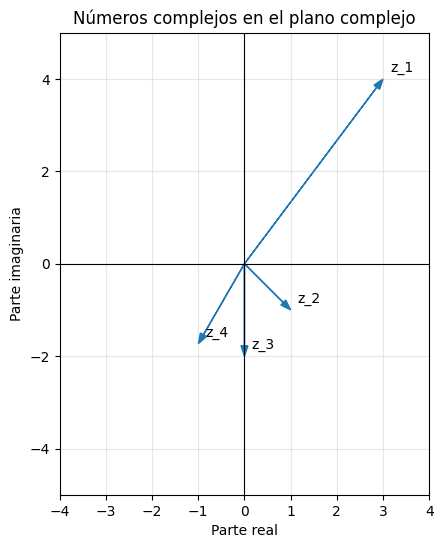

In [3]:
# --- REPRESENTACIÓN EN EL PLANO COMPLEJO --- #
plt.figure(figsize=(6, 6))

for nombre, z in numeros.items():
    plt.arrow(0, 0, z.real, z.imag, head_width=0.15, length_includes_head=True, color="tab:blue")
    plt.text(z.real + 0.15, z.imag + 0.15, nombre)

plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlim(-4, 4)
plt.ylim(-5, 5)
plt.gca().set_aspect("equal")
plt.title("Números complejos en el plano complejo")
plt.xlabel("Parte real")
plt.ylabel("Parte imaginaria")
plt.grid(True, alpha=0.3)
plt.show()

**Responde:**

1. ¿Puede el módulo ser negativo?

No, el módulo es la raíz cuadrada de $a^2+b^2$, que es una suma de cuadrados, así que siempre es mayor o igual que 0. Representa la distancia del número al origen del plano complejo.

2. ¿Qué relación existe entre la fase de un número y la de su conjugado?

Son opuestas: si $z$ tiene fase $\theta$, su conjugado $z^*$ tiene fase $-\theta$ (es el simétrico respecto al eje real). Por ejemplo, $z_1$ tiene fase $0{,}927$ rad y $z_1^*$ tendría $-0{,}927$ rad. El módulo es el mismo.

3. ¿En qué cuadrante se encuentra cada número?

- $z_1=3+4i$: primer cuadrante (parte real e imaginaria positivas).
- $z_2=1-i$: cuarto cuadrante (real positiva, imaginaria negativa).
- $z_3=-2i$: no está en ningún cuadrante, está sobre el eje imaginario negativo (fase de $-90^\circ$).
- $z_4=-1-\sqrt{3}i$: tercer cuadrante (ambas partes negativas).

4. ¿Por qué conviene utilizar `np.angle()` en lugar de calcular simplemente $\arctan(b/a)$?

Porque $\arctan(b/a)$ solo devuelve ángulos entre $-\pi/2$ y $\pi/2$, por lo que no distingue entre $z$ y $-z$ (por ejemplo, $1+i$ y $-1-i$ darían los dos $\pi/4$). Además falla cuando $a=0$ por la división entre 0. `np.angle()` usa los signos de las dos partes y devuelve el ángulo correcto en el cuadrante que toca.

## Ejercicio 2. Potencias de $i$

Calcula manualmente $i^{15}$, $i^{26}$, $i^{51}$ e $i^{100}$. Después comprueba los resultados con Python.

**Desarrollo manual:** como $i^4=1$, solo importa el resto de dividir el exponente entre 4.

- $i^{15}$: $15=4\cdot3+3$, así que $i^{15}=i^3=-i$.
- $i^{26}$: $26=4\cdot6+2$, así que $i^{26}=i^2=-1$.
- $i^{51}$: $51=4\cdot12+3$, así que $i^{51}=i^3=-i$.
- $i^{100}$: $100=4\cdot25+0$, así que $i^{100}=i^0=1$.

In [4]:
potencias = [15, 26, 51, 100]

for potencia in potencias:
    print(1j ** potencia)

(-0-1j)
(-1+0j)
(-0-1j)
(1+0j)


**Responde:** ¿Cada cuántas potencias se repite el patrón? ¿Cómo interviene el resto de dividir el exponente entre 4?

**Respuesta:** Cada 4. En este caso el resto es lo que importa y es de lo que depende unicamente el resultado. 

## Ejercicio 3. Cuadrado y módulo al cuadrado

Para $z=(1+i)/2$, calcula manualmente $z^2$, $z^*$, $z^*z$, $|z|$ y $|z|^2$. Después compruébalo con NumPy.

**Desarrollo manual:** con $z=\frac{1+i}{2}$:

$$z^2=\frac{(1+i)^2}{4}=\frac{1+2i+i^2}{4}=\frac{2i}{4}=\frac{i}{2}$$

$$z^*=\frac{1-i}{2}$$

$$z^*z=\frac{(1-i)(1+i)}{4}=\frac{1-i^2}{4}=\frac{2}{4}=\frac{1}{2}$$

$$|z|=\sqrt{\left(\tfrac{1}{2}\right)^2+\left(\tfrac{1}{2}\right)^2}=\sqrt{\tfrac{1}{2}}=\frac{\sqrt{2}}{2}\approx0{,}7071,\qquad |z|^2=\frac{1}{2}$$

In [5]:
z = (1 + 1j) / 2

cuadrado = z**2
conjugado = z.real - z.imag * 1j
producto_conjugado = z * conjugado
modulo = np.sqrt(z.real**2 + z.imag**2)
modulo_cuadrado = modulo**2

print("z²:", cuadrado)
print("z*:", conjugado)
print("z*z:", producto_conjugado)
print("|z|:", modulo)
print("|z|²:", modulo_cuadrado)

# --- COMPROBACIÓN CON NUMPY --- #
print("z* coincide con np.conj:", np.isclose(conjugado, np.conj(z)))
print("|z| coincide con np.abs:", np.isclose(modulo, np.abs(z)))

z²: 0.5j
z*: (0.5-0.5j)
z*z: (0.5+0j)
|z|: 0.7071067811865476
|z|²: 0.5000000000000001
z* coincide con np.conj: True
|z| coincide con np.abs: True


**Responde:**

1. ¿Por qué $z^2$ no puede utilizarse como probabilidad?

Por que para que el valor sea válido, las probabilides, es decir, el valor al cuadrado tiene que ser real. En general $z^2$ es un número complejo (en este caso $z^2=i/2$, un imaginario puro) y hasta puede ser negativo, así que no sirve. La probabilidad se calcula con $|z|^2=z^*z$.

2. ¿Por qué $z^*z$ siempre es real y no negativo?

Porque si $z=a+bi$, entonces $z^*z=(a-bi)(a+bi)=a^2+b^2$, que es una suma de cuadrados de números reales. Los términos con $i$ se cancelan.

3. ¿Puede una amplitud tener módulo mayor que 1 en un estado normalizado?

No, para estar normalizado el módulo debe de ser como máximo 1. Esto es porque $|\alpha|^2+|\beta|^2=1$ y ambos sumandos son no negativos, así que ninguno puede superar 1.

## Ejercicio 4. Forma cartesiana y polar

Implementa funciones para obtener el módulo y la fase de un número complejo y para reconstruirlo a partir de su forma polar.

In [6]:
def datos_polares(z):

    z = complex(z)
    mod = np.sqrt(z.real**2 + z.imag**2)
    phase = np.angle(z)
    phaseDeg = np.degrees(phase)

    return [mod, phase, phaseDeg]


def crear_complejo(modulo, fase):
    return modulo * (np.cos(fase) + np.sin(fase) * 1j)


numeros_polares = [1 + 1j, -1 + 1j, -1j, 2 * np.exp(1j * np.pi / 3)]

for num in numeros_polares:
    [mod, phase, phaseDeg] = datos_polares(num)
    print(f"Módulo: {mod:.3f} | Fase = {phase:.3f} | Fase en grados = {phaseDeg:.3f}")
    print(f"Complejo = {num:.3f} | De nuevo a complejo desde polar = {crear_complejo(mod, phase):.3f}")

Módulo: 1.414 | Fase = 0.785 | Fase en grados = 45.000
Complejo = 1.000+1.000j | De nuevo a complejo desde polar = 1.000+1.000j
Módulo: 1.414 | Fase = 2.356 | Fase en grados = 135.000
Complejo = -1.000+1.000j | De nuevo a complejo desde polar = -1.000+1.000j
Módulo: 1.000 | Fase = -1.571 | Fase en grados = -90.000
Complejo = -0.000-1.000j | De nuevo a complejo desde polar = 0.000-1.000j
Módulo: 2.000 | Fase = 1.047 | Fase en grados = 60.000
Complejo = 1.000+1.732j | De nuevo a complejo desde polar = 1.000+1.732j


**Responde:** ¿Por qué dos fases que difieren en $2\pi$ representan el mismo número complejo?

**Respuesta:** Significa que ha dado una vuelta, es decir, que está en el mismo lugar exactamente solo que tras completar una vuelta completea. Esto singifica que es el mismo número.

# Parte B. Notación de Dirac y producto interno

## Ejercicio 5. Del *ket* al *bra*

Representa

$$|\psi\rangle=\frac{1}{\sqrt2}\begin{pmatrix}1\\i\end{pmatrix}$$

como array unidimensional y como matriz columna. Obtén el *bra* asociado en ambos casos y muestra sus formas con `shape`.

In [7]:
# --- REPRESENTACIÓN COMO VECTOR Y COMO COLUMNA --- #
psi_vector = np.array([1, 1j], dtype="complex") / np.sqrt(2)
psi_columna = psi_vector.reshape(2, 1)

def toKet(z):
    return z.reshape(2, 1)

def toBra(z):
    if(z.shape != (2, 1)):
        z = z.reshape(2, 1)

    return np.conj(z).T

# --- CALCULAMOS LOS BRAS CORRESPONDIENTES --- #
bra_vector = np.conj(psi_vector)
bra_columna = toBra(psi_columna)
ket = toKet(psi_vector)

# --- MOSTRAMOS VALORES Y SHAPES --- #
print(f"Ket (vector) = {psi_vector}\n Shape: {psi_vector.shape}\n")
print(f"Ket (columna) = {psi_columna}\n Shape: {psi_columna.shape}\n")
print(f"Transpuesta del vector (sin conjugar) = {psi_vector.T}\n Shape: {psi_vector.T.shape}\n")
print(f"Bra (desde el vector) = {bra_vector}\n Shape: {bra_vector.shape}\n")
print(f"Bra (desde la columna) = {bra_columna}\n Shape: {bra_columna.shape}\n")

Ket (vector) = [0.70711+0.j      0.     +0.70711j]
 Shape: (2,)

Ket (columna) = [[0.70711+0.j     ]
 [0.     +0.70711j]]
 Shape: (2, 1)

Transpuesta del vector (sin conjugar) = [0.70711+0.j      0.     +0.70711j]
 Shape: (2,)

Bra (desde el vector) = [0.70711-0.j      0.     -0.70711j]
 Shape: (2,)

Bra (desde la columna) = [[0.70711-0.j      0.     -0.70711j]]
 Shape: (1, 2)



**Responde:**

1. ¿Por qué `psi_vector.T` no cambia la forma del array?

Porque es un array unidimensional, con forma `(2,)`, y no tiene una segunda dimensión que intercambiar. Para que la transposición tenga efecto necesitamos una matriz de dos dimensiones, como la columna de forma `(2, 1)`.

2. ¿Qué operación debe realizarse además de la transposición?

Hay que conjugar cada una de las componentes. El *bra* es el conjugado transpuesto del *ket*, no solo su transpuesto, así que usamos `np.conj(z).T`.

3. ¿Qué formas tienen el *ket* columna y su *bra*?

El *ket* columna tiene forma `(2, 1)` y su *bra* tiene forma `(1, 2)`, es decir, una fila.

## Ejercicio 6. Producto interno

Implementa $\langle a|b\rangle$ sin utilizar inicialmente `np.vdot()`. Recuerda conjugar el primer vector.

In [8]:
def producto_interno(estado_a, estado_b):
    """Calcula <estado_a|estado_b>."""

    a = np.asarray(estado_a, dtype=complex)
    b = np.asarray(estado_b, dtype=complex)

    if(a.shape != (2,) or b.shape != (2,)):
        raise ValueError("Los estados deben tener dos amplitudes")

    # Conjugamos el primer vector.
    return np.sum(np.conj(a) * b)


# --- <0|0>, <1|1>, <0|1> Y <1|0> --- #
combinaciones = {
    "<0|0>": (ket_0, ket_0),
    "<1|1>": (ket_1, ket_1),
    "<0|1>": (ket_0, ket_1),
    "<1|0>": (ket_1, ket_0),
}

# --- COMPARACIÓN CON np.vdot() --- #
for nombre, (a, b) in combinaciones.items():
    resultado = producto_interno(a, b)
    referencia = np.vdot(a, b)
    print(f"{nombre} = {resultado: .5f} | np.vdot = {referencia: .5f} | Coinciden: {np.isclose(resultado, referencia)}")

<0|0> =  1.00000+0.00000j | np.vdot =  1.00000+0.00000j | Coinciden: True
<1|1> =  1.00000+0.00000j | np.vdot =  1.00000+0.00000j | Coinciden: True
<0|1> =  0.00000+0.00000j | np.vdot =  0.00000+0.00000j | Coinciden: True
<1|0> =  0.00000+0.00000j | np.vdot =  0.00000+0.00000j | Coinciden: True


## Ejercicio 7. Propiedades del producto interno

Construye

$$|\psi\rangle=\frac{|0\rangle+i|1\rangle}{\sqrt2},\qquad
|\phi\rangle=\frac{|0\rangle-|1\rangle}{\sqrt2}.$$

Comprueba que $\langle\psi|\phi\rangle=\langle\phi|\psi\rangle^*$.

In [9]:
# --- CONSTRUIMOS psi Y phi --- #
psi = np.array([1, 1j], dtype=complex) / np.sqrt(2)
phi = np.array([1, -1], dtype=complex) / np.sqrt(2)

producto_psi_phi = producto_interno(psi, phi)
producto_phi_psi = producto_interno(phi, psi)

print("<psi|phi> =", producto_psi_phi)
print("<phi|psi> =", producto_phi_psi)

# --- COMPROBAMOS LA RELACIÓN DE CONJUGACIÓN --- #
assert np.isclose(producto_psi_phi, np.conj(producto_phi_psi))
print("Se cumple <psi|phi> = <phi|psi>*")

# --- QUÉ PASA SI NO CONJUGAMOS EL PRIMER VECTOR --- #
sin_conjugar = np.sum(psi * psi)
print("<psi|psi> sin conjugar =", sin_conjugar)
print("<psi|psi> conjugando   =", producto_interno(psi, psi))

<psi|phi> = (0.4999999999999999+0.4999999999999999j)
<phi|psi> = (0.4999999999999999-0.4999999999999999j)
Se cumple <psi|phi> = <phi|psi>*
<psi|psi> sin conjugar = 0j
<psi|psi> conjugando   = (0.9999999999999998+0j)


**Responde:**

1. ¿El producto interno debe ser real?

No, en general es un número complejo, como pasa con $\langle\psi|\phi\rangle=\frac{1+i}{2}$. Solo es real en casos concretos, como cuando calculamos el producto de un estado consigo mismo, que da su norma al cuadrado.

2. ¿Qué propiedad se cumple al intercambiar los estados?

Se cumple la simetría conjugada: $\langle\psi|\phi\rangle=\langle\phi|\psi\rangle^*$. Al intercambiar los estados obtenemos el conjugado del resultado.

3. ¿Qué error aparece si no se conjuga el primer vector?

Que dejamos de calcular un producto interno válido. Por ejemplo, con $|\psi\rangle$ el resultado de $\langle\psi|\psi\rangle$ sin conjugar es $0$ en lugar de $1$, así que un estado normalizado parecería tener norma cero, y se rompe la relación entre producto interno y norma.

# Parte C. Ortogonalidad y bases

## Ejercicio 8. Bases $X$ e $Y$

Construye los estados $|+\rangle$, $|-\rangle$, $|+i\rangle$ y $|-i\rangle$. Para cada uno muestra el vector, la norma, las probabilidades en la base computacional y su fase relativa.

In [10]:
# --- CONSTRUIMOS LOS ESTADOS --- #
ket_plus = np.array([1, 1], dtype=complex) / np.sqrt(2)
ket_minus = np.array([1, -1], dtype=complex) / np.sqrt(2)
ket_mas_i = np.array([1, 1j], dtype=complex) / np.sqrt(2)
ket_menos_i = np.array([1, -1j], dtype=complex) / np.sqrt(2)

estados_bases = {
    "|+>": ket_plus,
    "|->": ket_minus,
    "|+i>": ket_mas_i,
    "|-i>": ket_menos_i,
}

# --- NORMA, PROBABILIDADES Y FASE RELATIVA DE CADA ESTADO --- #
for nombre, estado in estados_bases.items():

    norma = np.linalg.norm(estado)
    probabilidades = np.abs(estado)**2
    faseRelativa = np.angle(estado[1]) - np.angle(estado[0])

    print(f"{nombre:<5} = {estado} | Norma = {norma:.5f} | P(0) = {probabilidades[0]:.5f} | P(1) = {probabilidades[1]:.5f} | "
          f"Fase relativa = {faseRelativa: .5f} rad ({np.degrees(faseRelativa): .1f} grados)")

|+>   = [0.70711+0.j 0.70711+0.j] | Norma = 1.00000 | P(0) = 0.50000 | P(1) = 0.50000 | Fase relativa =  0.00000 rad ( 0.0 grados)
|->   = [ 0.70711+0.j -0.70711+0.j] | Norma = 1.00000 | P(0) = 0.50000 | P(1) = 0.50000 | Fase relativa =  3.14159 rad ( 180.0 grados)
|+i>  = [0.70711+0.j      0.     +0.70711j] | Norma = 1.00000 | P(0) = 0.50000 | P(1) = 0.50000 | Fase relativa =  1.57080 rad ( 90.0 grados)
|-i>  = [ 0.70711+0.j      -0.     -0.70711j] | Norma = 1.00000 | P(0) = 0.50000 | P(1) = 0.50000 | Fase relativa = -1.57080 rad (-90.0 grados)


**Responde:**

1. ¿Producen los cuatro estados las mismas probabilidades en la base computacional?

Sí, en los cuatro casos $|\alpha|^2=|\beta|^2=\frac{1}{2}$, por lo que todos dan $P(0)=P(1)=0{,}5$.

2. ¿Son el mismo estado?

No, son cuatro estados distintos, aunque en la base computacional no se puedan diferenciar.

3. ¿Qué información los diferencia?

La fase relativa entre las amplitudes de $|0\rangle$ y $|1\rangle$: $0$ para $|+\rangle$, $\pi$ para $|-\rangle$, $\pi/2$ para $|+i\rangle$ y $-\pi/2$ para $|-i\rangle$.

4. ¿Qué pares deben ser ortogonales?

Los dos estados de cada base: $|+\rangle$ con $|-\rangle$, y $|+i\rangle$ con $|-i\rangle$ (y también $|0\rangle$ con $|1\rangle$).

## Ejercicio 9. Comprobación de ortogonalidad

Implementa una función que valide los estados y determine si su producto interno es aproximadamente cero.

In [11]:
def son_ortogonales(estado_a, estado_b, tolerancia=1e-10):
    """Devuelve True si dos estados válidos son ortogonales."""

    if(not es_estado_valido(estado_a, tolerancia) or not es_estado_valido(estado_b, tolerancia)):
        raise ValueError("Los estados deben ser válidos")

    producto = producto_interno(estado_a, estado_b)
    return bool(np.isclose(np.abs(producto), 0.0, atol=tolerancia))


pares = [
    ("|0>, |1>", ket_0, ket_1),
    ("|+>, |->", ket_plus, ket_minus),
    ("|+i>, |-i>", ket_mas_i, ket_menos_i),
    ("|0>, |+>", ket_0, ket_plus),
    ("|1>, |->", ket_1, ket_minus),
    ("|+>, |+i>", ket_plus, ket_mas_i),
]

# --- PRODUCTO INTERNO, MÓDULO Y ORTOGONALIDAD DE CADA PAR --- #
for nombre, a, b in pares:
    producto = producto_interno(a, b)
    print(f"Par: {nombre:<11} | Producto interno = {producto: .5f} | Módulo = {np.abs(producto):.5f} | Ortogonales: {son_ortogonales(a, b)}")

Par: |0>, |1>    | Producto interno =  0.00000+0.00000j | Módulo = 0.00000 | Ortogonales: True
Par: |+>, |->    | Producto interno =  0.00000+0.00000j | Módulo = 0.00000 | Ortogonales: True
Par: |+i>, |-i>  | Producto interno =  0.00000+0.00000j | Módulo = 0.00000 | Ortogonales: True
Par: |0>, |+>    | Producto interno =  0.70711+0.00000j | Módulo = 0.70711 | Ortogonales: False
Par: |1>, |->    | Producto interno = -0.70711+0.00000j | Módulo = 0.70711 | Ortogonales: False
Par: |+>, |+i>   | Producto interno =  0.50000+0.50000j | Módulo = 0.70711 | Ortogonales: False


## Ejercicio 10. Base ortonormal

Implementa una función que compruebe que dos estados están normalizados y son ortogonales.

In [12]:
def es_base_ortonormal(estado_a, estado_b, tolerancia=1e-10):
    """Determina si dos estados forman una base ortonormal de un qubit."""

    # Ambos estados deben estar normalizados.
    if(not es_estado_valido(estado_a, tolerancia) or not es_estado_valido(estado_b, tolerancia)):
        return False

    # Y además ser ortogonales entre sí.
    return son_ortogonales(estado_a, estado_b, tolerancia)


bases = {
    "base_Z": (ket_0, ket_1),
    "base_X": (ket_plus, ket_minus),
    "base_Y": (ket_mas_i, ket_menos_i),
    "base_repetida": (ket_0, ket_0),
    "no_ortogonal": (ket_0, ket_plus),
    "no_normalizada": (np.array([1, 1], dtype=complex), ket_1),
}

# --- EVALUAMOS Y JUSTIFICAMOS CADA CASO --- #
for nombre, (a, b) in bases.items():

    normaA = np.linalg.norm(a)
    normaB = np.linalg.norm(b)
    moduloProducto = np.abs(producto_interno(a, b))

    print(f"{nombre:<15} | Norma A = {normaA:.5f} | Norma B = {normaB:.5f} | |<a|b>| = {moduloProducto:.5f} | Base ortonormal: {es_base_ortonormal(a, b)}")

base_Z          | Norma A = 1.00000 | Norma B = 1.00000 | |<a|b>| = 0.00000 | Base ortonormal: True
base_X          | Norma A = 1.00000 | Norma B = 1.00000 | |<a|b>| = 0.00000 | Base ortonormal: True
base_Y          | Norma A = 1.00000 | Norma B = 1.00000 | |<a|b>| = 0.00000 | Base ortonormal: True
base_repetida   | Norma A = 1.00000 | Norma B = 1.00000 | |<a|b>| = 1.00000 | Base ortonormal: False
no_ortogonal    | Norma A = 1.00000 | Norma B = 1.00000 | |<a|b>| = 0.70711 | Base ortonormal: False
no_normalizada  | Norma A = 1.41421 | Norma B = 1.00000 | |<a|b>| = 1.00000 | Base ortonormal: False


## Ejercicio 11. Cambio de base

Los coeficientes de $|\psi\rangle$ en una base ortonormal $\{|u\rangle,|v\rangle\}$ son $\langle u|\psi\rangle$ y $\langle v|\psi\rangle$.

In [13]:
def coordenadas_en_base(estado, base):
    """Calcula las coordenadas de un estado en una base ortonormal."""

    if(not es_base_ortonormal(base[0], base[1])):
        raise ValueError("La base debe de ser ortonormal")

    if(not es_estado_valido(estado)):
        raise ValueError("El estado debe de ser válido")

    # Cada coordenada es el producto interno <u|psi> con el vector de la base.
    return np.array([producto_interno(u, estado) for u in base])


base_Z = [ket_0, ket_1]
base_X = [ket_plus, ket_minus]
base_Y = [ket_mas_i, ket_menos_i]

casos_cambio = {
    "|0> en X": (ket_0, base_X),
    "|1> en X": (ket_1, base_X),
    "|+> en Z": (ket_plus, base_Z),
    "|-i> en Y": (ket_menos_i, base_Y),
}

# --- COORDENADAS Y RECONSTRUCCIÓN DE CADA ESTADO --- #
for nombre, (estado, base) in casos_cambio.items():

    coordenadas = coordenadas_en_base(estado, base)
    reconstruido = coordenadas[0] * base[0] + coordenadas[1] * base[1]

    print(f"{nombre:<10} | Coordenadas = {coordenadas} | Reconstruido = {reconstruido} | Coincide: {np.allclose(reconstruido, estado)}")

|0> en X   | Coordenadas = [0.70711+0.j 0.70711+0.j] | Reconstruido = [1.+0.j 0.+0.j] | Coincide: True
|1> en X   | Coordenadas = [ 0.70711+0.j -0.70711+0.j] | Reconstruido = [0.+0.j 1.+0.j] | Coincide: True
|+> en Z   | Coordenadas = [0.70711+0.j 0.70711+0.j] | Reconstruido = [0.70711+0.j 0.70711+0.j] | Coincide: True
|-i> en Y  | Coordenadas = [0.+0.j 1.+0.j] | Reconstruido = [0.70711+0.j      0.     -0.70711j] | Coincide: True


**Responde:**

1. ¿Cambiar de base modifica el estado físico?

No, el estado físico es el mismo. Solo cambia la forma de describirlo, igual que un mismo punto del plano tiene distintas coordenadas según los ejes que elijamos.

2. ¿Qué cambia?

Cambian las coordenadas (las amplitudes) con las que escribimos el estado y, por tanto, las probabilidades de los resultados al medir en esa base. Por ejemplo, $|0\rangle$ es $(1,0)$ en $Z$ pero $\left(\frac{1}{\sqrt2},\frac{1}{\sqrt2}\right)$ en $X$.

3. ¿Qué coordenadas debe tener $|-i\rangle$ en la base $Y$?

Debe tener $(0,1)$, ya que $|-i\rangle$ es el segundo vector de la base $Y$: $\langle+i|-i\rangle=0$ y $\langle-i|-i\rangle=1$.

# Parte D. Fase global y fase relativa

## Ejercicio 12. Comparación de estados

Considera:

$$|\psi_A\rangle=\frac{1}{\sqrt2}(1,i)^T,\quad
|\psi_B\rangle=\frac{1}{\sqrt2}(i,-1)^T,$$

$$|\psi_C\rangle=\frac{1}{\sqrt2}(1,-i)^T,\quad
|\psi_D\rangle=-\frac{1}{\sqrt2}(1,i)^T.$$

Comprueba sus normas y probabilidades. Calcula el producto interno de $A$ con cada estado y determina cuáles son físicamente equivalentes a $A$.

In [14]:
# --- REPRESENTAMOS LOS ESTADOS --- #
psi_A = np.array([1, 1j], dtype=complex) / np.sqrt(2)
psi_B = np.array([1j, -1], dtype=complex) / np.sqrt(2)
psi_C = np.array([1, -1j], dtype=complex) / np.sqrt(2)
psi_D = -np.array([1, 1j], dtype=complex) / np.sqrt(2)

estados_fase = {
    "psi_A": psi_A,
    "psi_B": psi_B,
    "psi_C": psi_C,
    "psi_D": psi_D,
}

# --- COMPARAMOS CADA ESTADO CON psi_A --- #
for nombre, estado in estados_fase.items():

    norma = np.linalg.norm(estado)
    probabilidades = np.abs(estado)**2
    producto = producto_interno(psi_A, estado)
    equivalente = np.isclose(np.abs(producto), 1.0)

    print(f"{nombre} | Norma = {norma:.5f} | P(0) = {probabilidades[0]:.5f} | P(1) = {probabilidades[1]:.5f} | "
          f"<A|{nombre[-1]}> = {producto: .5f} | |<A|{nombre[-1]}>| = {np.abs(producto):.5f} | Equivalente a A: {equivalente}")

psi_A | Norma = 1.00000 | P(0) = 0.50000 | P(1) = 0.50000 | <A|A> =  1.00000+0.00000j | |<A|A>| = 1.00000 | Equivalente a A: True
psi_B | Norma = 1.00000 | P(0) = 0.50000 | P(1) = 0.50000 | <A|B> =  0.00000+1.00000j | |<A|B>| = 1.00000 | Equivalente a A: True
psi_C | Norma = 1.00000 | P(0) = 0.50000 | P(1) = 0.50000 | <A|C> =  0.00000+0.00000j | |<A|C>| = 0.00000 | Equivalente a A: False
psi_D | Norma = 1.00000 | P(0) = 0.50000 | P(1) = 0.50000 | <A|D> = -1.00000+0.00000j | |<A|D>| = 1.00000 | Equivalente a A: True


**Responde:**

1. ¿Qué factor relaciona $A$ con $B$?

El factor $i$: $|\psi_B\rangle=i|\psi_A\rangle$, ya que $i\cdot(1,i)=(i,-1)$. Es una fase global de $\pi/2$, y coincide con el resultado del producto interno, $\langle A|B\rangle=i$.

2. ¿Y $A$ con $D$?

El factor $-1$: $|\psi_D\rangle=-|\psi_A\rangle=e^{i\pi}|\psi_A\rangle$. También es una fase global, y el producto interno es $\langle A|D\rangle=-1$.

3. ¿Por qué $A$ y $C$ no son equivalentes aunque produzcan las mismas probabilidades?

Porque se diferencian en la fase relativa: en $A$ la segunda amplitud es $i$ y en $C$ es $-i$, así que no hay un único factor que multiplique a todo el vector. De hecho $\langle A|C\rangle=0$, son ortogonales ($|+i\rangle$ y $|-i\rangle$), es decir, lo más distintos posible, aunque en la base computacional den $P(0)=P(1)=0{,}5$ los dos.

## Ejercicio 13. Equivalencia salvo fase global

Para estados normalizados, utiliza el criterio $|\langle\psi|\phi\rangle|=1$. No dividas componentes, porque alguna podría ser cero.

In [15]:
def equivalentes_fase_global(estado_a, estado_b, tolerancia=1e-10):
    """Determina si dos estados válidos difieren solo en una fase global."""

    if(not es_estado_valido(estado_a, tolerancia) or not es_estado_valido(estado_b, tolerancia)):
        raise ValueError("Los estados deben ser válidos")

    # Criterio: |<a|b>| = 1 (sin dividir componentes).
    producto = producto_interno(estado_a, estado_b)
    return bool(np.isclose(np.abs(producto), 1.0, atol=tolerancia, rtol=0.0))


# --- PRUEBAS CON ESTADOS EQUIVALENTES Y NO EQUIVALENTES --- #
pruebas_fase = [
    ("psi_A, psi_B", psi_A, psi_B),
    ("psi_A, psi_D", psi_A, psi_D),
    ("|0>, i|0>", ket_0, 1j * ket_0),
    ("|+>, e^(i pi/3)|+>", ket_plus, np.exp(1j * np.pi / 3) * ket_plus),
    ("psi_A, psi_C", psi_A, psi_C),
    ("|+>, |->", ket_plus, ket_minus),
    ("|0>, |1>", ket_0, ket_1),
    ("|0>, |+>", ket_0, ket_plus),
]

for nombre, a, b in pruebas_fase:
    print(f"Par: {nombre:<20} | |<a|b>| = {np.abs(producto_interno(a, b)):.5f} | Equivalentes: {equivalentes_fase_global(a, b)}")

Par: psi_A, psi_B         | |<a|b>| = 1.00000 | Equivalentes: True
Par: psi_A, psi_D         | |<a|b>| = 1.00000 | Equivalentes: True
Par: |0>, i|0>            | |<a|b>| = 1.00000 | Equivalentes: True
Par: |+>, e^(i pi/3)|+>   | |<a|b>| = 1.00000 | Equivalentes: True
Par: psi_A, psi_C         | |<a|b>| = 0.00000 | Equivalentes: False
Par: |+>, |->             | |<a|b>| = 0.00000 | Equivalentes: False
Par: |0>, |1>             | |<a|b>| = 0.00000 | Equivalentes: False
Par: |0>, |+>             | |<a|b>| = 0.70711 | Equivalentes: False


**Responde:**

1. ¿Por qué es problemático dividir una componente entre otra?

Porque la componente por la que dividimos puede ser cero (como en $|0\rangle$ o $|1\rangle$) y entonces tenemos una división entre 0. Además, con números en coma flotante una componente casi nula (por ejemplo $10^{-17}$) daría cocientes enormes e inestables.

2. ¿Por qué el módulo del producto interno elimina la fase global?

Si $|\phi\rangle=e^{i\theta}|\psi\rangle$, entonces $\langle\psi|\phi\rangle=e^{i\theta}\langle\psi|\psi\rangle=e^{i\theta}$. Al tomar el módulo, $|e^{i\theta}|=1$, y la fase desaparece, solo queda el resultado 1.

3. ¿Puede aplicarse directamente el criterio a vectores no normalizados?

No. Para vectores no normalizados, si $|\phi\rangle=e^{i\theta}|\psi\rangle$ se cumple $|\langle\psi|\phi\rangle|=\|\psi\|\,\|\phi\|$, que no tiene por qué ser 1. Habría que normalizarlos antes (o comparar con el producto de normas).

# Pruebas mínimas

Ejecuta estas pruebas para comprobar que las funciones implementadas funcionan correctamente, incluyendo las entradas no válidas.

In [16]:
# --- PRUEBAS MÍNIMAS --- #

# Números complejos.
assert np.isclose(1j**15, -1j)
assert np.isclose(1j**26, -1)
assert np.isclose(1j**51, -1j)
assert np.isclose(1j**100, 1)
assert np.isclose(np.abs(z_4), 2.0)
assert np.isclose(np.angle(z_4), -2 * np.pi / 3)

mod, phase, phaseDeg = datos_polares(1 + 1j)
assert np.isclose(crear_complejo(mod, phase), 1 + 1j)

# Bras y kets.
assert psi_columna.shape == (2, 1)
assert bra_columna.shape == (1, 2)
assert np.allclose(bra_columna.flatten(), np.conj(psi_vector))

# Producto interno.
assert np.isclose(producto_interno(ket_0, ket_0), 1.0)
assert np.isclose(producto_interno(ket_0, ket_1), 0.0)
assert np.isclose(producto_interno(psi, phi), np.vdot(psi, phi))
assert np.isclose(producto_interno(psi, phi), np.conj(producto_interno(phi, psi)))

# Ortogonalidad y bases.
assert son_ortogonales(ket_plus, ket_minus)
assert son_ortogonales(ket_mas_i, ket_menos_i)
assert not son_ortogonales(ket_0, ket_plus)
assert es_base_ortonormal(ket_0, ket_1)
assert es_base_ortonormal(ket_plus, ket_minus)
assert not es_base_ortonormal(ket_0, ket_0)
assert not es_base_ortonormal(np.array([1, 1], dtype=complex), ket_1)

# Cambio de base.
assert np.allclose(coordenadas_en_base(ket_menos_i, base_Y), [0, 1])
assert np.allclose(coordenadas_en_base(ket_0, base_X), [1 / np.sqrt(2), 1 / np.sqrt(2)])

# Fase global y relativa.
assert equivalentes_fase_global(psi_A, psi_B)
assert equivalentes_fase_global(psi_A, psi_D)
assert not equivalentes_fase_global(psi_A, psi_C)

# --- PRUEBAS DE ENTRADAS NO VÁLIDAS --- #
entradas_invalidas = [
    lambda: producto_interno([1, 0, 0], ket_0),
    lambda: son_ortogonales([1, 1], ket_0),
    lambda: son_ortogonales([0, 0], ket_0),
    lambda: son_ortogonales([np.nan, 0], ket_0),
    lambda: equivalentes_fase_global([1, 1], ket_0),
    lambda: coordenadas_en_base(ket_0, [ket_0, ket_0]),
    lambda: coordenadas_en_base([1, 1], base_Z),
]

for funcion in entradas_invalidas:
    try:
        funcion()
        assert False, "Debería haberse lanzado un ValueError"
    except ValueError:
        pass

print("Todas las pruebas se han ejecutado correctamente.")

Todas las pruebas se han ejecutado correctamente.


## Conclusión

**Conclusión:**

En esta práctica hemos visto que la amplitud de un estado es un número complejo, y que la probabilidad sale de su módulo al cuadrado $|z|^2=z^*z$, nunca de $z^2$, porque este último puede ser complejo. Hemos representado los *kets* como vectores columna y los *bras* como su conjugado transpuesto, y hemos comprobado que el producto interno exige conjugar el primer vector. Con él hemos medido la ortogonalidad y construido bases ortonormales ($Z$, $X$ e $Y$), y hemos calculado coordenadas de un mismo estado en distintas bases sin cambiar el estado físico. Por último, hemos diferenciado entre fase global, que no se puede observar (criterio $|\langle\psi|\phi\rangle|=1$), y fase relativa, que da estados distintos aunque tengan las mismas probabilidades en la base computacional.